In [1]:
# download the data
!pip install opendatasets
import opendatasets as od
od.download('https://www.kaggle.com/datasets/milobele/sentiment140-dataset-1600000-tweets')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: silenthope
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/milobele/sentiment140-dataset-1600000-tweets


100%|██████████| 81.0M/81.0M [00:02<00:00, 32.7MB/s]


In [2]:
# import the libraries
import pandas as pd
df_train= pd.read_csv('/content/sentiment140-dataset-1600000-tweets/training.1600000.processed.noemoticon.csv', encoding='Latin1')
df_train.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [3]:
df_train.columns

Index(['0', '1467810369', 'Mon Apr 06 22:19:45 PDT 2009', 'NO_QUERY',
       '_TheSpecialOne_',
       '@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D'],
      dtype='object')

In [4]:
df_train.shape

(1599999, 6)

In [5]:
import torch
device= 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [6]:
# import the dependicies
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report

In [7]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [8]:
# printing the stopwords in english
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

**Data processing **

In [9]:
df_train.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [10]:
# naming the cols and reading the data again
columns_names=['target', 'id', 'date', 'flag', 'user', 'text']
df_train= pd.read_csv('/content/sentiment140-dataset-1600000-tweets/training.1600000.processed.noemoticon.csv',names= columns_names, encoding='Latin1')
df_train.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [11]:
df_train.shape

(1600000, 6)

In [12]:
df_train.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


<Axes: xlabel='target'>

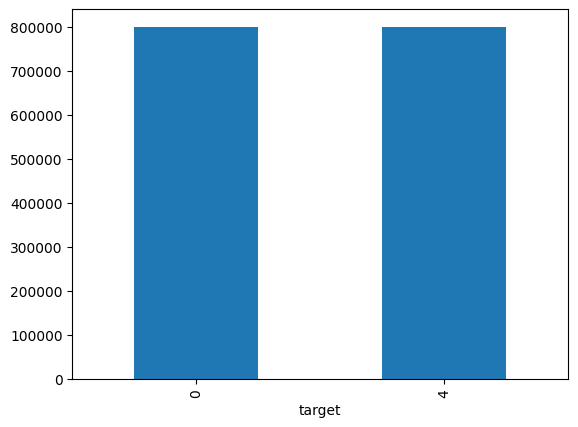

In [13]:
df_train['target'].value_counts().plot(kind='bar')

In [14]:
df_train.loc[df_train['target']== 4, 'target']= 1



stemming is the process of reducing a word to its root word

In [15]:
port_stem= PorterStemmer()
def stemming (content):
  stemmed_content= re.sub('[^a-zA-Z]' ,' ', content)
  stemmed_content=stemmed_content.lower()
  stemmed_content=stemmed_content.split()
  stemmed_content=[port_stem.stem(word) for word in stemmed_content if word not in stopwords.words('english')]
  stemmed_content=' '.join(stemmed_content)


  return stemmed_content

In [16]:
df_train['stemmed_content']= df_train['text'].apply(stemming)

In [17]:
# separating the data and label
X= df_train['stemmed_content'].values
y= df_train['target'].values
X.shape , y.shape

((1600000,), (1600000,))

In [18]:
# splitting the data
X_train  ,X_test , y_train , y_test = train_test_split(X,y  ,test_size=0.2 ,stratify=y, random_state=2)

In [19]:
X_train.shape  ,X_test.shape , y_train.shape , y_test.shape

((1280000,), (320000,), (1280000,), (320000,))

In [20]:
# coverting the textual data to numerical data
vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [21]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
lr.score(X_train, y_train)

0.79871953125

In [23]:
y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7767
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.77    160000
           1       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



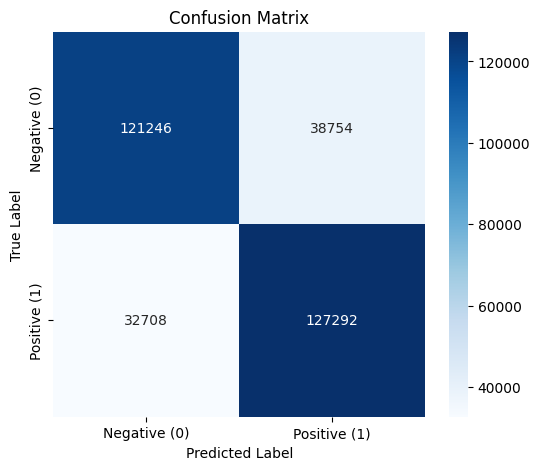

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

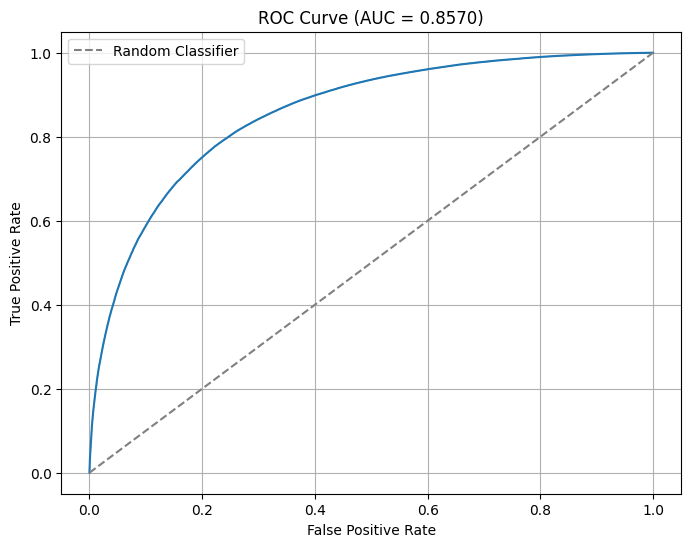

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get the probabilities of the positive class
y_pred_proba = lr.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {auc:.4f})')
plt.grid(True)
plt.legend()
plt.show()

In [24]:
import joblib

# Save the trained model
joblib.dump(lr, 'logistic_regression_model.pkl')
print("Model saved as 'logistic_regression_model.pkl'")

Model saved as 'logistic_regression_model.pkl'


In [25]:
# Load the model
loaded_lr = joblib.load('logistic_regression_model.pkl')
print("Model reloaded successfully.")

Model reloaded successfully.


Now, let's test the reloaded model on a sample from the data (e.g., the 200th entry).

In [26]:
# Get the 200th sample from the original dataframe's stemmed content
sample_index = 199 # 0-indexed for 200th item
sample_text = df_train['stemmed_content'].iloc[sample_index]
actual_sentiment = df_train['target'].iloc[sample_index]

print(f"Original Tweet (stemmed): {sample_text}")
print(f"Actual Sentiment (0=negative, 1=positive): {actual_sentiment}")

# Transform the sample text using the same vectorizer
sample_vectorized = vectorizer.transform([sample_text])

# Make a prediction using the loaded model
predicted_sentiment = loaded_lr.predict(sample_vectorized)

print(f"Predicted Sentiment (0=negative, 1=positive): {predicted_sentiment[0]}")

Original Tweet (stemmed): get shit done today screw
Actual Sentiment (0=negative, 1=positive): 0
Predicted Sentiment (0=negative, 1=positive): 0
